In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

print("Python version:", sys.version.split()[0])
print("Libraries loaded successfully.")

Python version: 3.12.10
Libraries loaded successfully.


# 📊 Quotes Tag Analytics

### Web Scraping, Data Cleaning & Exploratory Analysis of 250 Quotes

This project collects, cleans, and analyzes a dataset of 250 unique quotes.

The analysis focuses on:

- Quote and author patterns
- Tag frequency and relationships
- Quote length and word count
- Author contribution
- Common tag combinations
- Visual exploration of the dataset

### Project Pipeline

**Data Collection → Data Cleaning → Exploratory Analysis → Visualization → Insights**

## 1. Project Overview

Quotes contain interesting patterns related to authors, topics, and writing style.

The goal of this project is to build a simple end-to-end data analysis workflow that:

1. Collects quote data using Python.
2. Combines the collected data into a single dataset.
3. Removes duplicate and invalid records.
4. Creates useful analytical features.
5. Analyzes authors, tags, and quote length.
6. Visualizes the main patterns in the dataset.

The final dataset contains **250 unique quotes** with information about their authors and associated tags.

In [2]:
PROJECT_ROOT = Path.cwd().parent
DATA_FILE = PROJECT_ROOT / "data" / "processed" / "quotes_clean.csv"

df = pd.read_csv(DATA_FILE)

print("Dataset loaded successfully.")
print(f"Dataset location: {DATA_FILE}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

Dataset loaded successfully.
Dataset location: c:\Users\hp\OneDrive\Documents\GitHub Projects\Quotes-Tag-Analytics\data\processed\quotes_clean.csv
Rows: 250
Columns: 6


## 2. Dataset Overview

The cleaned dataset contains six columns:

| Column | Description |
|---|---|
| `quote` | Text of the quote |
| `author` | Author of the quote |
| `tags` | Associated tags |
| `tag_count` | Number of tags assigned to the quote |
| `quote_length` | Number of characters in the quote |
| `word_count` | Number of words in the quote |

In [3]:
df.head(10)

,quote,author,tags,tag_count,quote_length,word_count
0,“The world as we have created it is a process ...,Albert Einstein,"change, deep-thoughts, thinking, world",4,115,21
1,"“It is our choices, Harry, that show what we t...",J.K. Rowling,"abilities, choices",2,85,16
2,“There are only two ways to live your life. On...,Albert Einstein,"inspirational, life, live, miracle, miracles",5,131,26
3,"“The person, be it gentleman or lady, who has ...",Jane Austen,"aliteracy, books, classic, humor",4,104,19
4,"“Imperfection is beauty, madness is genius and...",Marilyn Monroe,"be-yourself, inspirational",2,111,16
5,“Try not to become a man of success. Rather be...,Albert Einstein,"adulthood, success, value",3,67,14
6,“It is better to be hated for what you are tha...,André Gide,"life, love",2,82,19
7,"“I have not failed. I've just found 10,000 way...",Thomas A. Edison,"edison, failure, inspirational, paraphrased",4,65,12
8,“A woman is like a tea bag; you never know how...,Eleanor Roosevelt,misattributed-eleanor-roosevelt,1,85,19
9,"“A day without sunshine is like, you know, nig...",Steve Martin,"humor, obvious, simile",3,50,9


## 3. Dataset Statistics

Let's examine the overall structure and basic statistics of the dataset.

In [4]:
print("Dataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nUnique Authors:")
print(df["author"].nunique())

print("\nUnique Tags:")
print(
    len(
        set(
            tag.strip()
            for tags in df["tags"].fillna("")
            for tag in tags.split(",")
            if tag.strip()
        )
    )
)

print("\nNumerical Summary:")
df[["tag_count", "quote_length", "word_count"]].describe()

Dataset Shape:
(250, 6)

Missing Values:
quote           0
author          0
tags            3
tag_count       0
quote_length    0
word_count      0
dtype: int64

Unique Authors:
156

Unique Tags:
146

Numerical Summary:


,tag_count,quote_length,word_count
count,250.000000,250.000000,250.000000
mean,1.712000,99.984000,18.852000
std,1.247107,92.418898,17.357744
min,0.000000,25.000000,5.000000
25%,1.000000,60.000000,11.000000
50%,1.000000,80.500000,16.000000
75%,2.000000,110.750000,21.000000
max,8.000000,1084.000000,201.000000


## 4. Key Metrics

The following metrics summarize the main characteristics of the quote dataset.

In [5]:
total_quotes = len(df)
unique_authors = df["author"].nunique()
unique_tags = len(
    set(
        tag.strip()
        for tags in df["tags"].fillna("")
        for tag in tags.split(",")
        if tag.strip()
    )
)

average_words = df["word_count"].mean()
average_length = df["quote_length"].mean()
average_tags = df["tag_count"].mean()

print(f"Total Quotes        : {total_quotes}")
print(f"Unique Authors      : {unique_authors}")
print(f"Unique Tags         : {unique_tags}")
print(f"Average Word Count  : {average_words:.2f}")
print(f"Average Quote Size  : {average_length:.2f} characters")
print(f"Average Tag Count   : {average_tags:.2f}")

Total Quotes        : 250
Unique Authors      : 156
Unique Tags         : 146
Average Word Count  : 18.85
Average Quote Size  : 99.98 characters
Average Tag Count   : 1.71


## 5. Author Analysis

This section examines which authors appear most frequently in the dataset.

In [6]:
top_authors = (
    df["author"]
    .value_counts()
    .head(10)
    .sort_values()
)

top_authors

author
Jane Austen             5
C.S. Lewis              5
Confucius               5
Richard Bach            5
Dr. Seuss               6
Mark Twain              6
Marilyn Monroe          7
Ralph Waldo Emerson     7
J.K. Rowling            9
Albert Einstein        10
Name: count, dtype: int64

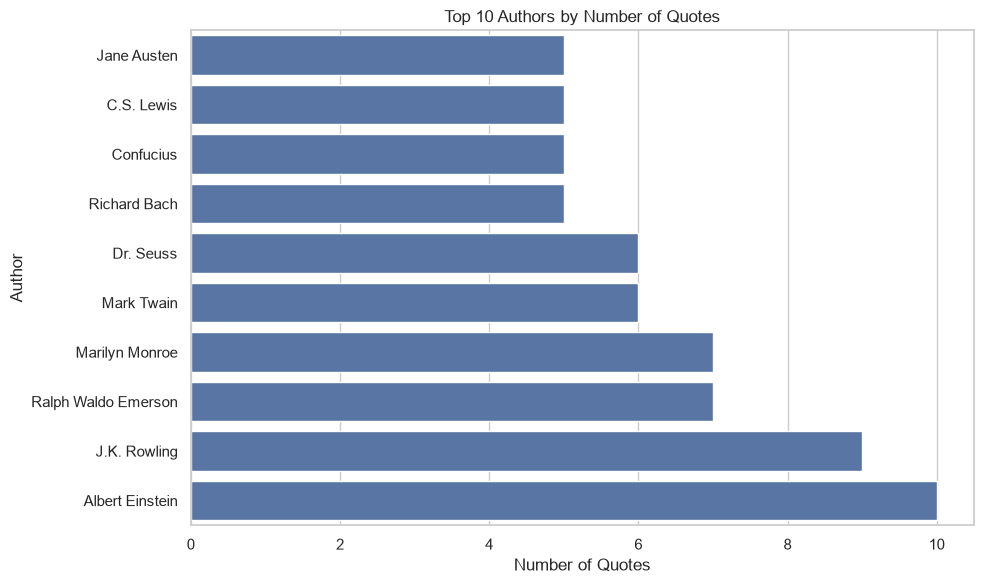

In [7]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_authors.values,
    y=top_authors.index
)

plt.title("Top 10 Authors by Number of Quotes")
plt.xlabel("Number of Quotes")
plt.ylabel("Author")

plt.tight_layout()
plt.show()

## 6. Tag Analysis

Tags provide a useful view of the major themes represented in the quote dataset.

We will identify the most frequently occurring tags and visualize the top 10.

In [8]:
from collections import Counter

all_tags = []

for tags in df["tags"].fillna(""):
    for tag in tags.split(","):
        tag = tag.strip()
        if tag:
            all_tags.append(tag)

tag_counts = (
    pd.Series(Counter(all_tags))
    .sort_values(ascending=False)
)

top_tags = tag_counts.head(10)

top_tags

famous quotes    70
wisdom           52
life             24
inspirational    22
success          21
friendship       17
love             16
humor            12
books            11
character         7
dtype: int64

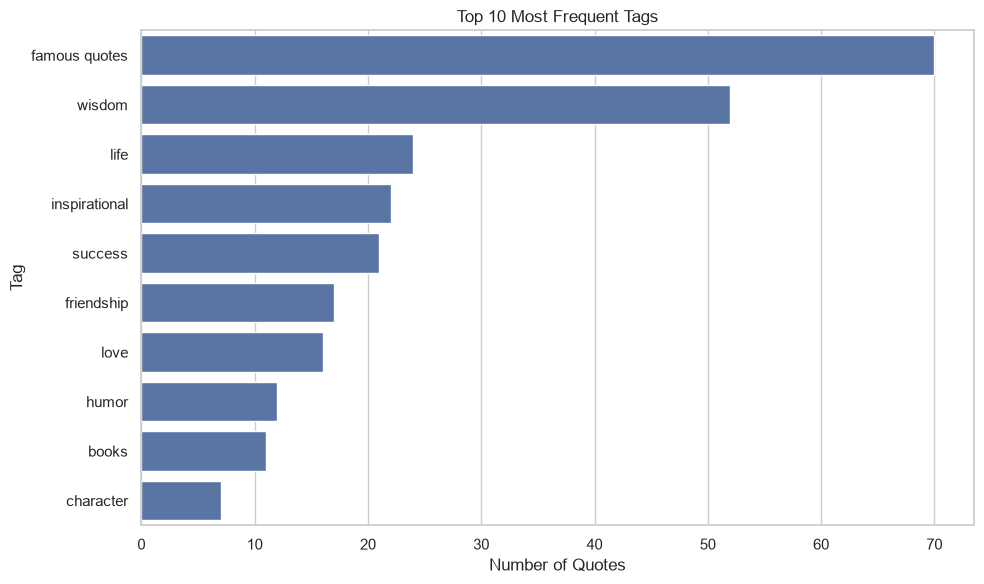

In [9]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_tags.values,
    y=top_tags.index
)

plt.title("Top 10 Most Frequent Tags")
plt.xlabel("Number of Quotes")
plt.ylabel("Tag")

plt.tight_layout()
plt.show()

## 7. Quote Length Analysis

This section examines the length of the quotes using both character count and word count.

These measurements help identify the general writing length within the dataset.

In [10]:
print(f"Average quote length: {df['quote_length'].mean():.2f} characters")
print(f"Average word count: {df['word_count'].mean():.2f} words")

print("\nLongest Quote:")
longest_quote = df.loc[df["quote_length"].idxmax()]

print(longest_quote["quote"])
print(f"Author: {longest_quote['author']}")

print("\nShortest Quote:")
shortest_quote = df.loc[df["quote_length"].idxmin()]

print(shortest_quote["quote"])
print(f"Author: {shortest_quote['author']}")

Average quote length: 99.98 characters
Average word count: 18.85 words

Longest Quote:
“This life is what you make it. No matter what, you're going to mess up sometimes, it's a universal truth. But the good part is you get to decide how you're going to mess it up. Girls will be your friends - they'll act like it anyway. But just remember, some come, some go. The ones that stay with you through everything - they're your true best friends. Don't let go of them. Also remember, sisters make the best friends in the world. As for lovers, well, they'll come and go too. And baby, I hate to say it, most of them - actually pretty much all of them are going to break your heart, but you can't give up because if you give up, you'll never find your soulmate. You'll never find that half who makes you whole and that goes for everything. Just because you fail once, doesn't mean you're gonna fail at everything. Keep trying, hold on, and always, always, always believe in yourself, because if you don't, t

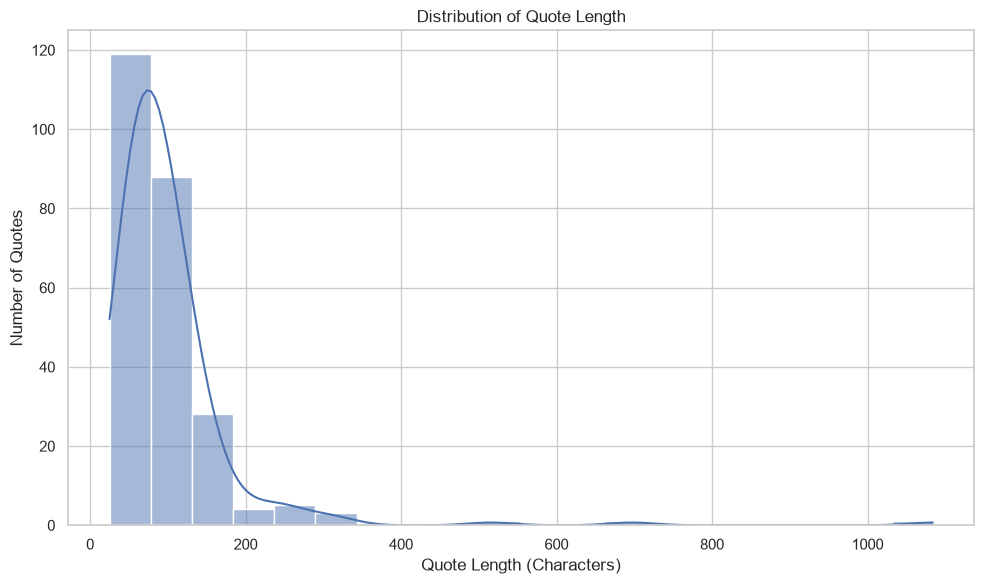

In [11]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["quote_length"],
    bins=20,
    kde=True
)

plt.title("Distribution of Quote Length")
plt.xlabel("Quote Length (Characters)")
plt.ylabel("Number of Quotes")

plt.tight_layout()
plt.show()

## 8. Word Count Analysis

The word-count distribution shows how concise or lengthy the quotes are across the dataset.

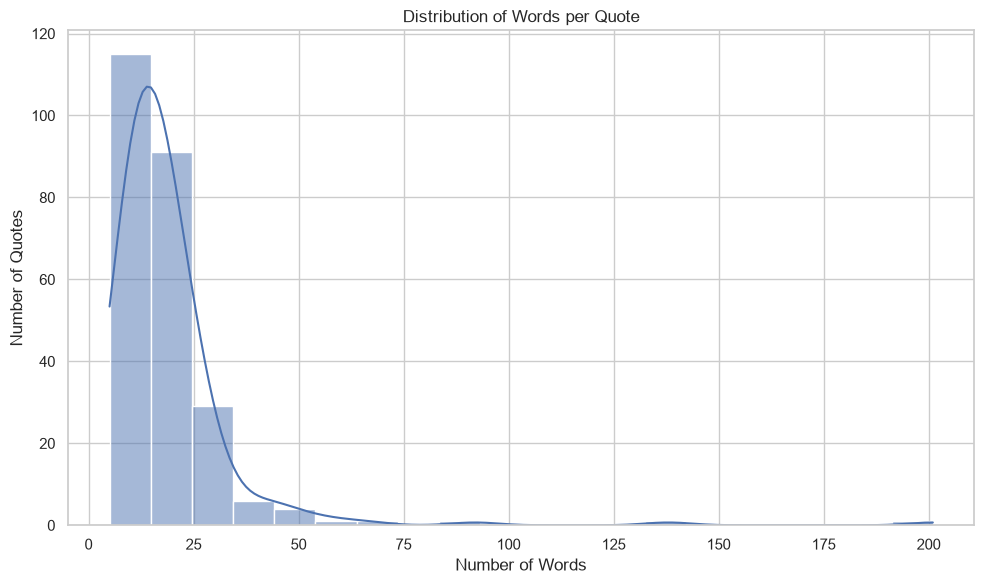

In [12]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["word_count"],
    bins=20,
    kde=True
)

plt.title("Distribution of Words per Quote")
plt.xlabel("Number of Words")
plt.ylabel("Number of Quotes")

plt.tight_layout()
plt.show()

## 9. Common Tag Combinations

Individual tags show popular themes, while tag combinations reveal themes that frequently appear together.

In [13]:
from itertools import combinations

tag_combinations = Counter()

for tags in df["tags"].fillna(""):
    tag_list = sorted({
        tag.strip()
        for tag in tags.split(",")
        if tag.strip()
    })

    for pair in combinations(tag_list, 2):
        tag_combinations[pair] += 1

top_combinations = tag_combinations.most_common(10)

combination_df = pd.DataFrame(
    top_combinations,
    columns=["Tag Combination", "Occurrences"]
)

combination_df

,Tag Combination,Occurrences
0,"(famous quotes, wisdom)",13
1,"(inspirational, life)",5
2,"(famous quotes, inspirational)",5
3,"(friendship, love)",4
4,"(books, reading)",4
5,"(famous quotes, success)",4
6,"(life, wisdom)",4
7,"(books, classic)",2
8,"(life, love)",2
9,"(friends, life)",2


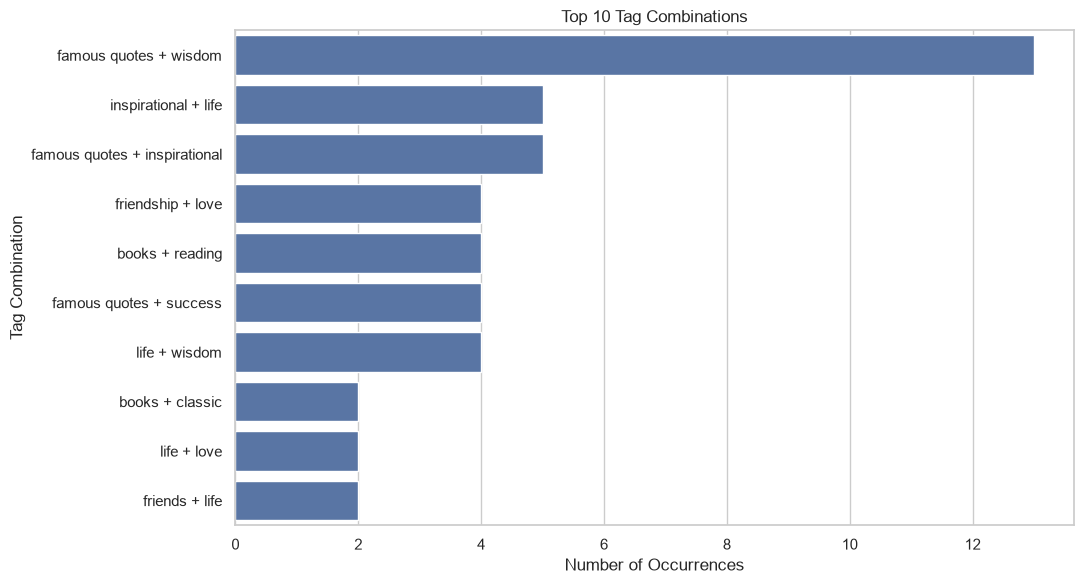

In [14]:
labels = [
    f"{pair[0]} + {pair[1]}"
    for pair, _ in top_combinations
]

values = [
    count
    for _, count in top_combinations
]

plt.figure(figsize=(11, 6))

sns.barplot(
    x=values,
    y=labels
)

plt.title("Top 10 Tag Combinations")
plt.xlabel("Number of Occurrences")
plt.ylabel("Tag Combination")

plt.tight_layout()
plt.show()

## 10. Quote Statistics by Author

This section examines the average quote length and word count for authors with multiple quotes in the dataset.

In [15]:
author_stats = (
    df.groupby("author")
    .agg(
        quote_count=("quote", "count"),
        average_words=("word_count", "mean"),
        average_length=("quote_length", "mean")
    )
    .sort_values(
        "quote_count",
        ascending=False
    )
)

author_stats.head(10)

,quote_count,average_words,average_length
author,,,
Albert Einstein,10,18.000000,93.700000
J.K. Rowling,9,22.000000,118.444444
Marilyn Monroe,7,45.142857,240.857143
Ralph Waldo Emerson,7,16.571429,87.857143
Dr. Seuss,6,21.166667,107.666667
Mark Twain,6,14.000000,73.166667
Richard Bach,5,15.200000,81.400000
Jane Austen,5,33.400000,171.800000
Confucius,5,23.600000,123.800000


## 11. Key Findings

The analysis of the 250-quote dataset highlights several patterns:

- The dataset contains **250 unique quotes** from **156 authors**.
- There are **146 unique tags** after normalizing tag capitalization.
- The average quote contains approximately **18.85 words**.
- The average quote length is approximately **99.98 characters**.
- The average quote contains approximately **1.71 tags**.
- **Albert Einstein** appears most frequently in the dataset with 10 quotes.
- **famous quotes**, **wisdom**, **life**, **inspirational**, and **success** are among the most frequent tags.
- Tag combinations reveal relationships between themes such as **famous quotes + wisdom**, **inspirational + life**, and **friendship + love**.
- Quote length varies considerably, showing that the dataset contains both short statements and substantially longer passages.

## 12. Conclusion

This project demonstrates a complete data-analysis workflow using Python.

The workflow covers:

**Data Collection → Data Cleaning → Feature Engineering → Exploratory Data Analysis → Visualization → Insights**

The project uses web scraping and public quote data to create a dataset of 250 unique quotes. Pandas is used for data processing and analysis, while Matplotlib and Seaborn are used to visualize patterns in authors, tags, quote length, word count, and tag relationships.

The resulting analysis provides a structured view of the themes and characteristics present in the quote dataset.

### Technologies Used

- Python
- Requests
- BeautifulSoup
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

### Project Output

The project produces:

- Cleaned quote dataset
- Author analysis
- Tag frequency analysis
- Quote length analysis
- Word count analysis
- Tag combination analysis
- Data visualizations

---

## 📌 Project Summary

| Component | Result |
|---|---:|
| Total Quotes | 250 |
| Unique Authors | 156 |
| Unique Tags | 146 |
| Average Words / Quote | 18.85 |
| Average Quote Length | 99.98 |
| Average Tags / Quote | 1.71 |

**Quotes Tag Analytics** demonstrates an end-to-end Python data analytics workflow, from collecting raw data to extracting meaningful patterns through visualization.